# GAME OF LIFE

### Python modules

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from IPython.display import HTML
import scipy as sp

### Implementing the rules

In [2]:
L = 50
frames = 500
interval = 100

def count_neighbors(world):
    return ( np.roll(world,1,0) + np.roll(world,-1,0) + np.roll(world,1,1) + np.roll(world,-1,1) +
             np.roll(np.roll(world,1,0),1,1) + np.roll(np.roll(world,1,0),-1,1) + 
             np.roll(np.roll(world,-1,0),1,1) + np.roll(np.roll(world,-1,0),-1,1) )

def evolve_convolution(world):
    kernel = np.ones((3,3))
    kernel[1,1] = 0
    neighbors = sp.signal.convolve2d(world, kernel, mode = 'same', boundary = 'wrap')
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

## Dynamic of the game 
We take a look at the time evolution of several worlds with the same initial density.

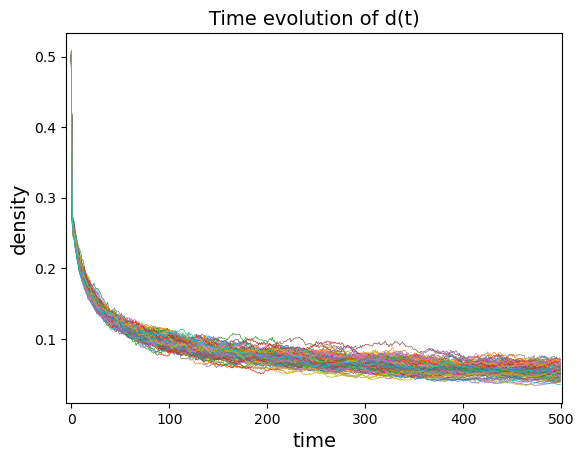

In [54]:
L = 150
T = 500
N = 100 #trajectories generated
time = np.arange(T)
initial_density = 0.5
densities = []
for i in range(N):
    aux_density = []
    world = np.random.random((L,L))
    world[world > initial_density] = 0
    world[world != 0] = 1
    for j in range(T):
        aux_density.append(np.sum(world)/L**2)
        world = evolve(world)
    plt.plot(time,aux_density, lw = 0.5)
    densities.append(aux_density)
plt.xlim(-5, 501) 
plt.xlabel("time", fontsize = 14)
plt.ylabel("density", fontsize = 14)
plt.title("Time evolution of d(t)", fontsize = 14)
plt.show()

The various generated worlds exhibit a similar d(t) function. Let's see how they are distributed at fixed times.

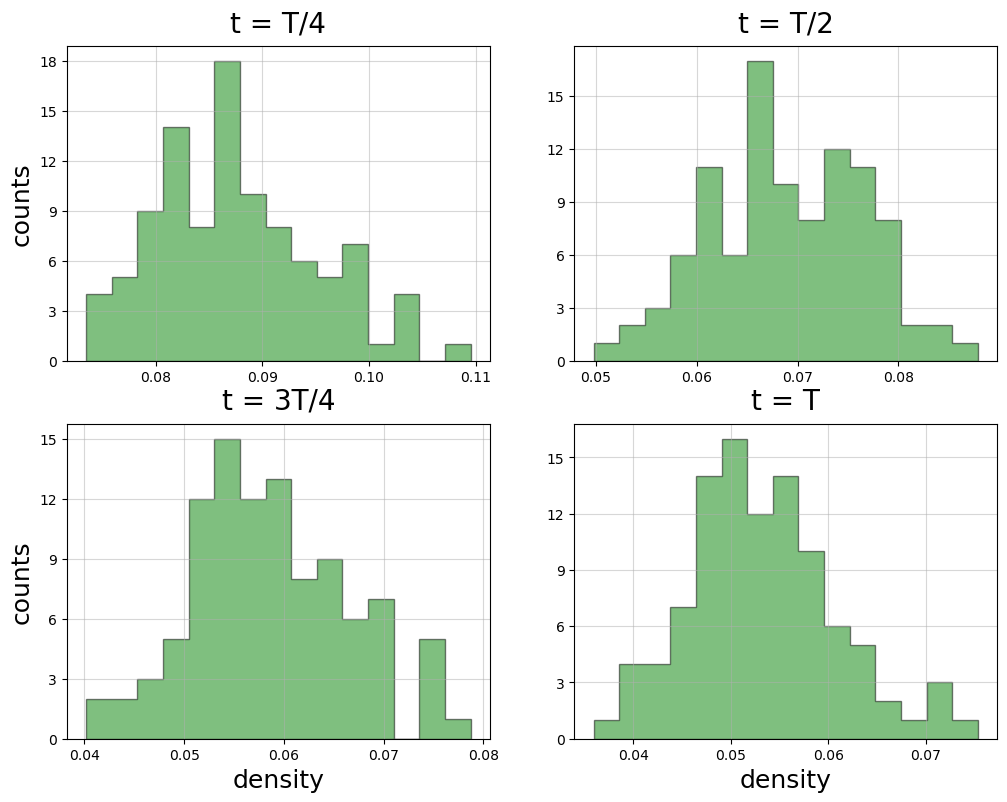

In [8]:
densities = np.array(densities)

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(12, 9))

ax[0][0].hist(densities[:,int(T/4)],15, histtype = 'stepfilled', alpha = 0.5, color = 'green', edgecolor = "black")
ax[0][0].yaxis.set_major_locator(MultipleLocator(3))
ax[0][0].xaxis.set_major_locator(MultipleLocator(0.01))
ax[0][0].set_title("t = T/4", fontsize=20, verticalalignment='bottom')
ax[0][0].grid(alpha=0.5)

ax[0][1].hist(densities[:,int(T/2)],15, histtype = 'stepfilled', alpha = 0.5, color = 'green', edgecolor = "black")
ax[0][1].yaxis.set_major_locator(MultipleLocator(3))
ax[0][1].xaxis.set_major_locator(MultipleLocator(0.01))
ax[0][1].set_title("t = T/2", fontsize=20, verticalalignment='bottom')
ax[0][1].grid(alpha=0.5)

ax[1][0].hist(densities[:,int(3*T/4)],15, histtype = 'stepfilled', alpha = 0.5, color = 'green', edgecolor = "black")
ax[1][0].yaxis.set_major_locator(MultipleLocator(3))
ax[1][0].xaxis.set_major_locator(MultipleLocator(0.01))
ax[1][0].set_title("t = 3T/4", fontsize=20, verticalalignment='bottom')
ax[1][0].grid(alpha=0.5)

ax[1][1].hist(densities[:,T-1],15, histtype = 'stepfilled', alpha = 0.5, color = 'green', edgecolor = "black")
ax[1][1].yaxis.set_major_locator(MultipleLocator(3))
ax[1][1].xaxis.set_major_locator(MultipleLocator(0.01))
ax[1][1].set_title("t = T", fontsize=20, verticalalignment='bottom')
ax[1][1].grid(alpha=0.5)

ax[1][0].set_xlabel("density", fontsize = 18)
ax[1][1].set_xlabel("density", fontsize = 18)
ax[0][0].set_ylabel("counts", fontsize = 18)
ax[1][0].set_ylabel("counts", fontsize = 18)

plt.show()

These seems to be well behaved distributions. We proceed by calculating mean trajectories and errors.

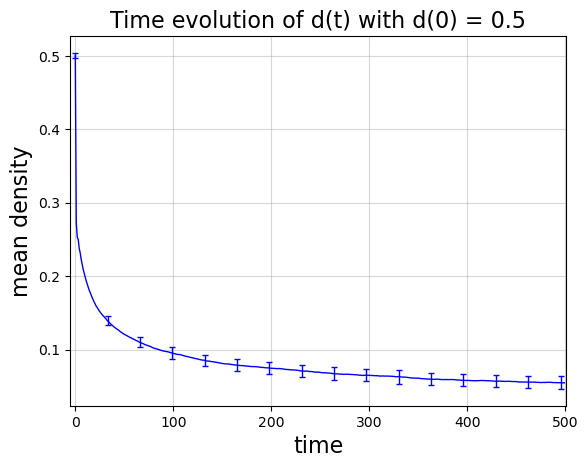

In [56]:
densities = np.array(densities)
mean_density = densities.mean(axis = 0)
std_density = densities.std(axis = 0)
idx = list(range(0,T,int(T/15)))
plt.errorbar(time[idx],mean_density[idx],std_density[idx], ls = '', lw = 1, capsize = 2, color = 'blue')
plt.plot(time,mean_density, ls = '-', lw = 1, color = 'blue')
plt.xlabel("time", fontsize = 16)
plt.ylabel("mean density", fontsize = 16)
plt.title("Time evolution of d(t) with d(0) = 0.5", fontsize = 16)
plt.grid(alpha = 0.5)
plt.xlim(-5, 501) 
plt.show()

Now let's see how different initial densities influence the time evolution.

In [57]:
L = 120
T = 2000
N = 50
initial_densities = [0.05, 0.1, 0.15, 0.2, 0.5, 0.6, 0.7, 0.75]

mean_densities = []
mean_std = []
for d in initial_densities:
    densities = []
    for i in range(N):
        aux_density = []
        world = np.random.random((L,L))
        world[world > d] = 0
        world[world != 0] = 1
        for t in range(T):
            aux_density.append(np.sum(world)/L**2)
            world = evolve(world)
        densities.append(aux_density)
    mean_std.append(np.array(densities).std(axis=0))
    mean_densities.append(np.array(densities).mean(axis=0))

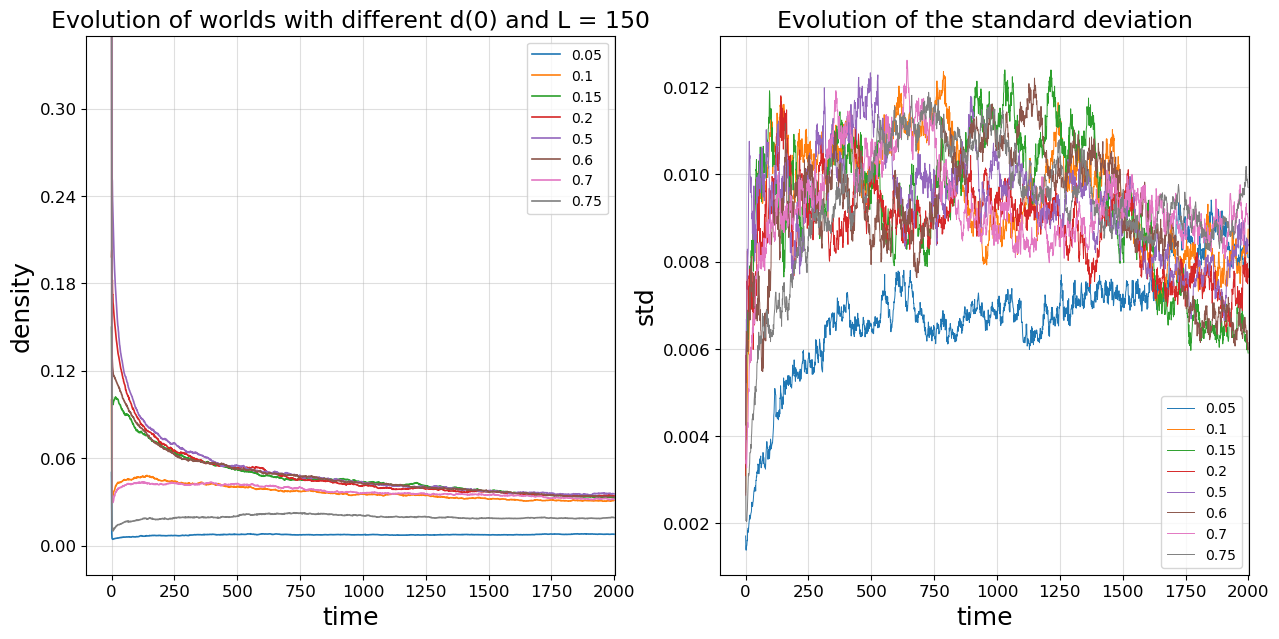

In [58]:
from matplotlib.ticker import MaxNLocator

fig, (ax1,ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (15,7))

for i in range(len(mean_densities)):
    ax1.plot(range(T), mean_densities[i], lw = 1.2, label = f"{initial_densities[i]}")
    ax2.plot(range(T), mean_std[i], lw = 0.7, label = f"{initial_densities[i]}")

ax1.set_xlabel("time", fontsize = 18)
ax1.set_ylabel("density", fontsize = 18)
ax1.set_title("Evolution of worlds with different d(0) and L = 150", fontsize = 17)
ax1.set_ylim(-0.02,0.35)
ax2.set_xlabel("time", fontsize = 18)
ax2.set_ylabel("std", fontsize = 18)
ax2.set_title("Evolution of the standard deviation", fontsize = 17)
ax1.legend()
ax2.legend()
ax1.grid(alpha = 0.4)
ax2.grid(alpha = 0.4)
ax1.tick_params(labelsize=12) 
ax1.yaxis.set_major_locator(MaxNLocator(nbins=7))
ax2.tick_params(labelsize=12) 
ax1.set_xlim(-100, 2002)
ax2.set_xlim(-100, 2002)
ax2.yaxis.set_major_locator(MaxNLocator(nbins=8))
plt.show()

In [59]:
T = 1000
N = [80,50,20,15,10,10,10]
L = [30,60,80,120,150,200,250]
d = 0.4

mean_densities = []
mean_std = []
for i in range(len(L)):
    densities = []
    for j in range(N[i]):
        aux_density = []
        world = np.random.random((L[i],L[i]))
        world[world > d] = 0
        world[world != 0] = 1
        for t in range(T):
            aux_density.append(np.sum(world)/L[i]**2)
            world = evolve(world)
        densities.append(aux_density)
    mean_std.append(np.array(densities).std(axis=0))
    mean_densities.append(np.array(densities).mean(axis=0))

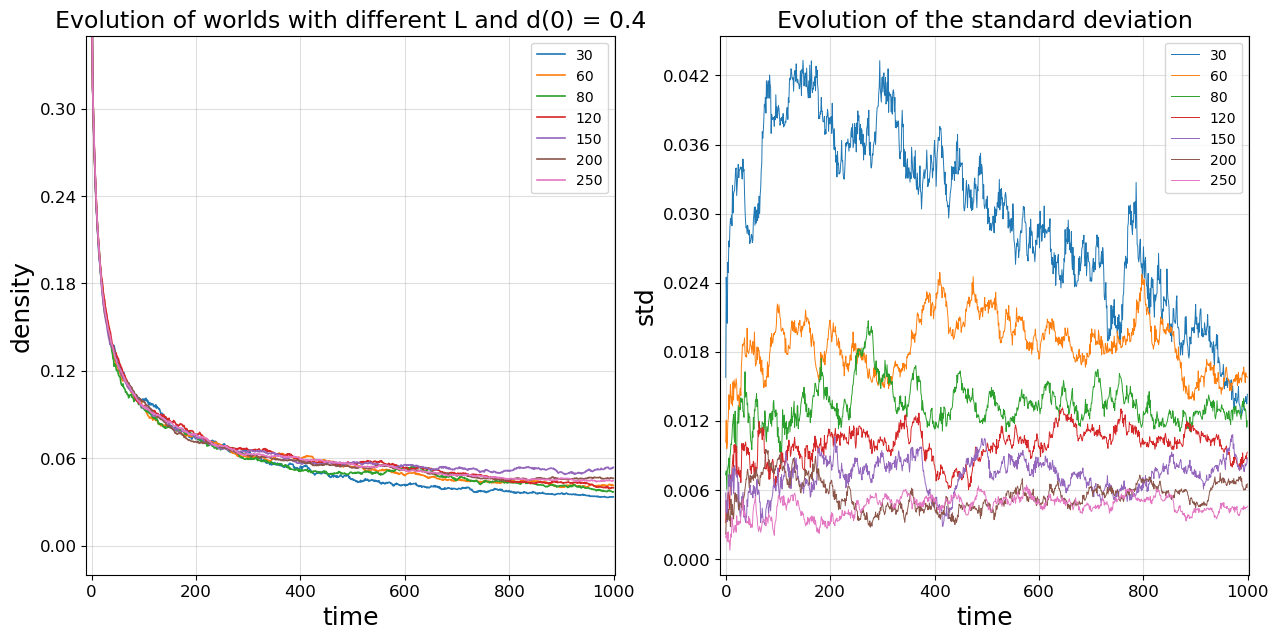

In [61]:
fig, (ax1,ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (15,7))

for i in range(len(mean_densities)):
    ax1.plot(range(T), mean_densities[i], lw = 1.2, label = f"{L[i]}")
    ax2.plot(range(T), mean_std[i], lw = 0.7, label = f"{L[i]}")

ax1.set_xlabel("time", fontsize = 18)
ax1.set_ylabel("density", fontsize = 18)
ax1.set_title("Evolution of worlds with different L and d(0) = 0.4", fontsize = 17)
ax1.set_ylim(-0.02,0.35)
ax2.set_xlabel("time", fontsize = 18)
ax2.set_ylabel("std", fontsize = 18)
ax2.set_title("Evolution of the standard deviation", fontsize = 17)
ax1.legend()
ax2.legend()
ax1.grid(alpha = 0.4)
ax2.grid(alpha = 0.4)
ax1.tick_params(labelsize=12) 
ax1.yaxis.set_major_locator(MaxNLocator(nbins=7))
ax2.tick_params(labelsize=12) 
ax2.yaxis.set_major_locator(MaxNLocator(nbins=9))
ax1.set_xlim(-10, 1002) 
ax2.set_xlim(-10, 1002) 
plt.show()

No matter of the initial density and the lattice size, many trajectories seem to converge to an asymptotic value. Let's have a closer look.

In [3]:
L = 80
T = 9000
DT = 500
N = 20
initial_densities = np.concatenate([np.arange(0,0.1,0.02), np.arange(0.1,0.7,0.1), np.arange(0.7, 0.9, 0.02)])
asymptotic_densities = []
std_densities = []
index = 1
for d in initial_densities:
    aux_density = []
    for i in range(N):
        world = np.random.random((L,L))
        world[world > d] = 0
        world[world != 0] = 1
        for t in range(T):
            world = evolve(world)
        for t in range(T+DT):
            aux_density.append(np.sum(world)/L**2)
            world = evolve(world)
    asymptotic_densities.append(np.array(aux_density).mean())
    std_densities.append(np.array(aux_density).std())
    print(index, " / ", len(initial_densities))
    index += 1


data = np.column_stack([initial_densities, asymptotic_densities, std_densities])
np.savetxt('dati_gol.txt', data, header='x y sigma_y', comments='')
print("Dati salvati in dati_gol.txt")

1  /  22
2  /  22
3  /  22
4  /  22
5  /  22
6  /  22
7  /  22
8  /  22
9  /  22
10  /  22
11  /  22
12  /  22
13  /  22
14  /  22
15  /  22
16  /  22
17  /  22
18  /  22
19  /  22
20  /  22
21  /  22
22  /  22
Dati salvati in dati_gol.txt


## Approaching the steady state
We saw that starting from an initial density in the range of 0.2-0.6 for large t we reach a steady state between 0.025 and 0.030. What large t means is still not clear, but based on our observations and on the article of interest t = 9000 should be enough. At this point we start from a fixed initial density and we generate many trajectories. For each of them we calculate $d(\infty)$ as the mean over time of $d(t)$ for $9000 < t < 9500$. We then calculate $d^*$ as the mean over all trajectories of the latter quantity. It is interesting to understand how $d(t)$ approaches the asymptotic density depending on the size of the lattice. To do so we start from an initial density of 0.4.

In [5]:
initial_density = 0.4
L = np.array([50,80,120,180,300])

T = 9000
DT = 500
N = np.array([60, 40, 20, 20, 10])

mean = []
std = []
for i in range(len(L)):
    print("Lattice size: ", L[i],"x", L[i])
    densities = []
    for j in range(N[i]):
        aux_density = []
        world = np.random.random((L[i],L[i]))
        world[world > initial_density] = 0
        world[world != 0] = 1
        for t in range(T):
            world = evolve(world)
        for t in range(T,T+DT):
            world = evolve(world)
            if(T%20 == 0):
                aux_density.append(np.sum(world)/L[i]**2)
        densities.append(np.mean(aux_density))
    print("mean: ", np.mean(densities))
    mean.append(np.mean(densities))
    print("mean error: ", np.std(densities)/np.sqrt(N[i]))
    std.append(np.std(densities)/np.sqrt(N[i]))

Lattice size:  50 x 50
mean:  0.02978666666666667
mean error:  0.000896286991075052
Lattice size:  80 x 80
mean:  0.029265625
mean error:  0.0009165164708865029
Lattice size:  120 x 120
mean:  0.028898166666666662
mean error:  0.0007607957468100077
Lattice size:  180 x 180
mean:  0.029637345679012345
mean error:  0.00043780336554738946
Lattice size:  300 x 300
mean:  0.029603364444444447
mean error:  0.00033861245235647293


In [6]:
w_error = np.sqrt(1/np.sum(np.pow((std[1:len(std)]),-2)))
w_mean = np.sum( mean[1:len(mean)]/np.pow(std[1:len(std)],2) )*w_error**2
print("weighted mean: ",w_mean, " +/- ", w_error)

weighted mean:  0.02951775363379747  +/-  0.0002435624253421101


In order to see how different lattice size on average approach the steady state, we run the following code.

In [7]:
initial_density = 0.4
L = np.array([40,80,120,170,200,250])
T = 5000

N = np.array([80,60,20,20,10,10]) #trajectories
mean_densities = []
mean_std = []
for i in range(len(L)):
    densities = []
    for j in range(N[i]):
        aux_density = []
        world = np.random.random((L[i],L[i]))
        world[world > initial_density] = 0
        world[world != 0] = 1
        for t in range(T):
            world = evolve(world)
            aux_density.append(np.sum(world)/L[i]**2 - w_mean)
        densities.append(aux_density)
    mean_densities.append(np.array(densities).mean(axis = 0))
    mean_std.append(np.array(densities).std(axis = 0))

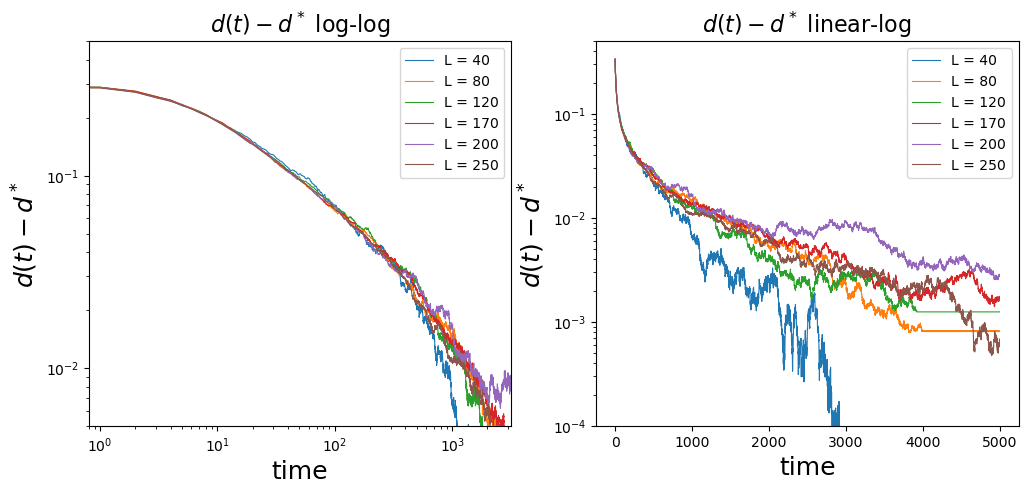

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,5))
for i in range(len(mean_densities)):
    ax[0].plot(range(T), mean_densities[i], lw = 0.8, label = f"L = {L[i]}")
ax[0].set_ylim(0.005,0.5)
ax[0].set_xlim(0.8,3200)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel("time")
ax[0].set_ylabel(r"$d(t)-d^*$")
ax[0].set_title(r"$d(t)-d^*$ log-log")
ax[0].legend()

for i in range(len(mean_densities)):
    ax[1].plot(range(T), mean_densities[i], lw = 0.8, label = f"L = {L[i]}")
ax[1].set_ylim(0.0001,0.5)
ax[1].set_yscale('log')
ax[1].set_xlabel("time")
ax[1].set_ylabel(r"$d(t)-d^*$")
ax[1].set_title(r"$d(t)-d^*$ linear-log")
ax[1].legend()
plt.show()

The log-log plot shows a linear relation between the quantities. As a consequence there is a time range where $d(\infty)-d^* \sim t^{-b}$. To make a rough estimate we select the mean trajectory of $L=250$ in a time range $20<t<100$, we calculate the log of the latter quantity and of time and we run a linear fit. The errors on $d(\infty)-d^*$ are calculated as <br>
$\frac{\sigma}{\sqrt{N}}$

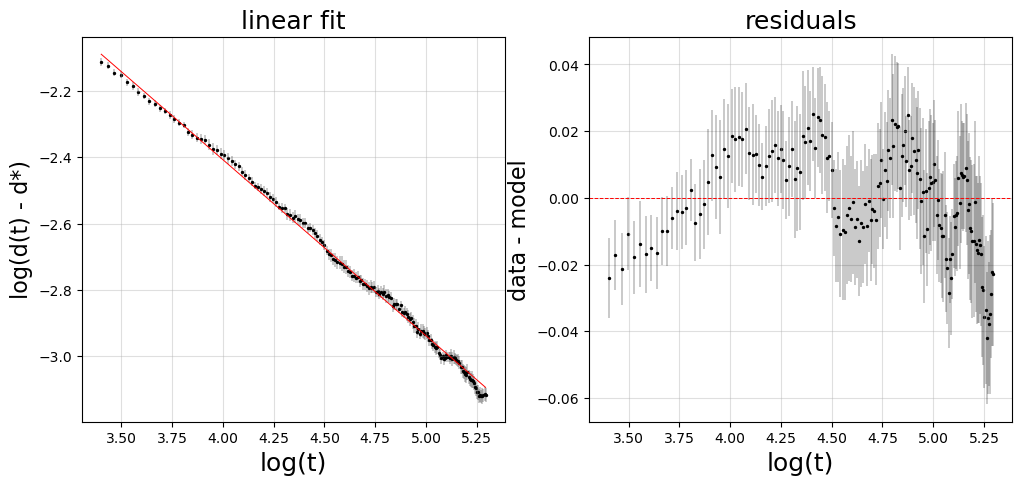

b:  0.001936024269770757


In [9]:
x = range(30,200)
y = np.array(mean_densities)[-1, x]
err = np.array(mean_std)[-1, x]

err = err/np.abs(y)
x = np.log(x)
y = np.log(y)


def func(x, m, q):
    return m*x + q
    
popt, pcov = sp.optimize.curve_fit(func, x, y, sigma = err)
#popt, pcov = sp.optimize.curve_fit(func, x, y)

b, q = popt
errb, errq = np.sqrt(np.diag(pcov))

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,5))
xlin = np.linspace(x.min(), x.max())
ax[0].scatter(x,y, s = 2, color = "black")
ax[0].errorbar(x, y, err/np.sqrt(N[-1]), capsize = 0, color = "black", ls = "", lw = 0.3)
ax[0].plot(xlin, func(xlin,b,q), color = "red", lw = 0.7)
ax[0].set_xlabel("log(t)", fontsize = 18)
ax[0].set_ylabel("log(d(t) - d*)", fontsize = 16)
ax[0].set_title("linear fit", fontsize = 18)
ax[0].grid(alpha = 0.4)


ax[1].scatter(x,y-func(x,b,q), s = 2, color = "black", )
ax[1].errorbar(x,y-func(x,b,q),err/np.sqrt(N[-1]),capsize = 0, color = "black", ls = "", lw = 0.3)
ax[1].axhline(0, color = "red", ls = "--", lw = 0.7)
ax[1].grid(alpha = 0.4)
ax[1].set_xlabel("log(t)", fontsize = 18)
ax[1].set_ylabel("data - model", fontsize = 16)
ax[1].set_title("residuals", fontsize = 18)

plt.show()

print("b: ", errb)
#print("b: ", -b, " +/- ", errb)

Similarly to the article's result.

### Activity
We define the activity as $a(t) = \frac{b(t)+d(t)}{N_a(t)}$ where $b(t), d(t)$ are the number of births and deaths and $N_a(t)$ is the number of live cells at time t. We can proceed by calculating time evolution and inferring some parameters as we have just done. 

In [4]:
initial_densities = [0.05, 0.1, 0.15, 0.2, 0.5, 0.6, 0.7, 0.75]
L = 150
T = 3000
time = np.arange(T)
N = 50 #trajectories
def evolve_with_activity(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    births = np.sum((world == 0) & (new_world == 1))
    deaths = np.sum((world == 1) & (new_world == 0))
    alive = np.sum(world)
    activity = (births + deaths)/alive
    return new_world, births/alive, deaths/alive, activity

mean_activities = []
mean_std = []
for i in range(len(initial_densities)):
    mean_activity = []
    for j in range(N):
        aux_activity = []
        world = np.random.random((L,L))
        world[world > initial_densities[i]] = 0
        world[world != 0] = 1
        for t in range(T):
            world, births, deaths, activity = evolve_with_activity(world)
            aux_activity.append(activity)
        mean_activity.append(aux_activity)    
    mean_activities.append(np.array(mean_activity).mean(axis = 0))
    mean_std.append(np.array(mean_activity).std(axis = 0))

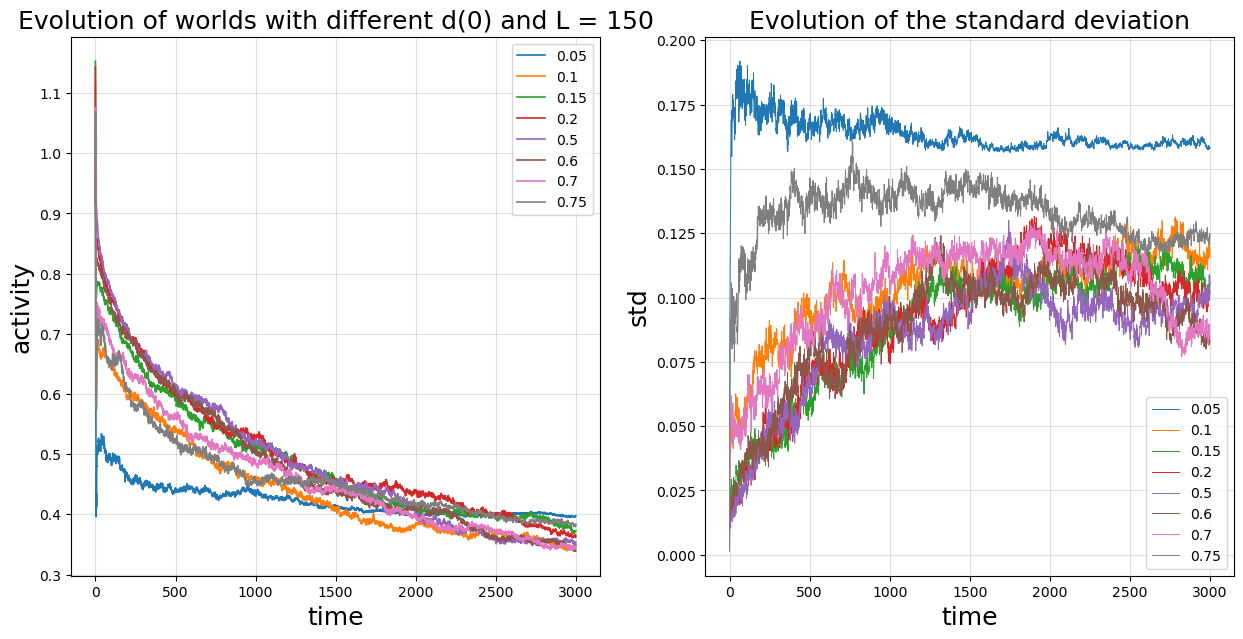

In [17]:
fig, (ax1,ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (15,7))

for i in range(len(mean_activities)):
    ax1.plot(range(T), mean_activities[i], lw = 1.2, label = f"{initial_densities[i]}")
    ax2.plot(range(T), mean_std[i], lw = 0.7, label = f"{initial_densities[i]}")

ax1.set_xlabel("time", fontsize = 18)
ax1.set_ylabel("activity", fontsize = 18)
ax1.set_title("Evolution of worlds with different d(0) and L = 150", fontsize = 18)
#ax1.set_ylim(-0.02,0.35)
ax2.set_xlabel("time", fontsize = 18)
ax2.set_ylabel("std", fontsize = 18)
ax2.set_title("Evolution of the standard deviation", fontsize = 18)
ax1.legend()
ax2.legend()
ax1.grid(alpha = 0.4)
ax2.grid(alpha = 0.4)
plt.show()

In [10]:
T = 3000
N = [80,50,20,15,10,10,10]
L = [30,60,80,120,150,200,250]
d = 0.4

mean_activities = []
mean_std = []
for i in range(len(L)):
    activities = []
    for j in range(N[i]):
        aux_activity = []
        world = np.random.random((L[i],L[i]))
        world[world > d] = 0
        world[world != 0] = 1
        for t in range(T):
            world, births, deaths, activity = evolve_with_activity(world)
            aux_activity.append(activity)
        activities.append(aux_activity)
    mean_std.append(np.array(activities).std(axis=0))
    mean_activities.append(np.array(activities).mean(axis=0))

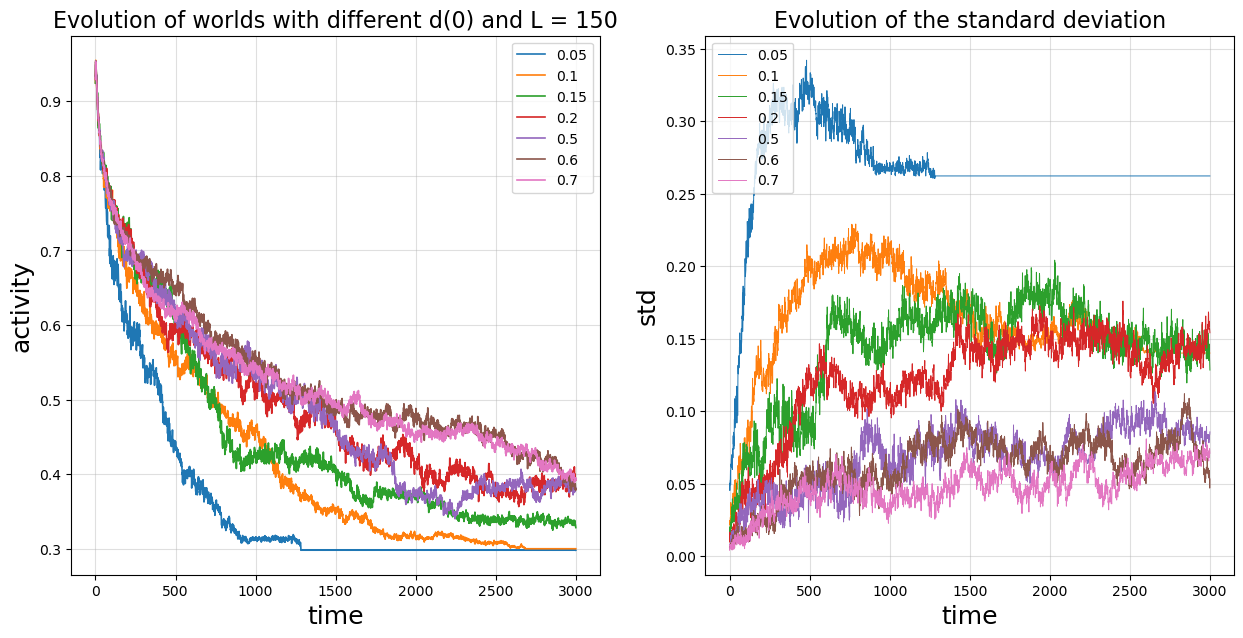

In [12]:
fig, (ax1,ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (15,7))

for i in range(len(mean_activities)):
    ax1.plot(range(T), mean_activities[i], lw = 1.2, label = f"{initial_densities[i]}")
    ax2.plot(range(T), mean_std[i], lw = 0.7, label = f"{initial_densities[i]}")

ax1.set_xlabel("time", fontsize = 18)
ax1.set_ylabel("activity", fontsize = 18)
ax1.set_title("Evolution of worlds with different d(0) and L = 150", fontsize = 16)
#ax1.set_ylim(-0.02,0.35)
ax2.set_xlabel("time", fontsize = 18)
ax2.set_ylabel("std", fontsize = 18)
ax2.set_title("Evolution of the standard deviation", fontsize = 16)
ax1.legend()
ax2.legend()
ax1.grid(alpha = 0.4)
ax2.grid(alpha = 0.4)
plt.show()

Similarly to what we saw for the density, It seems that there is an asymptotic value for the activity which is in common to many initial densities. It is interesting to study how fast worlds of different lattice size approach this limit. First things first, we need to have a value for the asymptotic limit.

In [13]:
initial_density = 0.4
L = np.array([50,100,150,200,300])
#L=np.array([50,100])

T = 9000
DT = 500
N = np.array([80,20,10,10,10])
time = np.arange(T,T+DT)

mean = []
std = []
for k in range(len(L)):
    print("Lattice size: ", L[k],"x", L[k])
    densities = []
    activities = []
    for i in range(N[k]):
        aux_density = []
        aux_activity = []
        world = np.random.random((L[k],L[k]))
        world[world > initial_density] = 0
        world[world != 0] = 1
        for j in range(T):
            world = evolve(world)
        for j in range(T,T+DT):
            world, births, deaths, activity = evolve_with_activity(world)
            aux_density.append(np.sum(world)/L[k]**2)
            aux_activity.append(activity)
        densities.append(aux_density)
        activities.append(aux_activity)
        
    print("mean asymptotic density: ", np.mean(np.array(densities)), " +/- ", np.std(np.array(densities)))
    print("mean asymptotic activity: ", np.mean(np.array(activities)), " +/- ", np.std(np.array(activities)))
    mean.append(np.mean(np.array(activities)))
    std.append(np.std(np.array(activities)))

Lattice size:  50 x 50
mean asymptotic density:  0.029830000000000002  +/-  0.006920773078204485
mean asymptotic activity:  0.3328487561218197  +/-  0.16631222040784063
Lattice size:  100 x 100
mean asymptotic density:  0.028275  +/-  0.0036012324279335265
mean asymptotic activity:  0.26573126159261423  +/-  0.08481853190020158
Lattice size:  150 x 150
mean asymptotic density:  0.02801333333333333  +/-  0.001999955555061718
mean asymptotic activity:  0.3262257838114135  +/-  0.06673805744305308
Lattice size:  200 x 200
mean asymptotic density:  0.02883295  +/-  0.0024058035139013327
mean asymptotic activity:  0.32018478966309133  +/-  0.04791157861686228
Lattice size:  300 x 300
mean asymptotic density:  0.028026093333333335  +/-  0.0013329154075313891
mean asymptotic activity:  0.30764422555349513  +/-  0.027942005659643453


In [14]:
w_error = np.sqrt(1/np.sum(np.pow((std[1:len(std)]),-2)))
w_mean = np.sum( mean[1:len(mean)]/np.pow(std[1:len(std)],2) )*w_error**2
print("weighted mean: ",w_mean, " +/- ", w_error)

weighted mean:  0.30947551930477774  +/-  0.02192665215803293


In [15]:
L = np.array([50, 100, 150, 200, 240])
N = np.array([100, 20, 10, 10, 10])
initial_density = 0.4
T = 5000

mean_activities = []
mean_std = []
for k in range(len(L)):
    mean_activity = []
    for i in range(N[k]):
        world = np.random.random((L[k],L[k]))
        world[world > initial_density] = 0
        world[world != 0] = 1
        aux_activity = []
        for t in range(T):
            world, births, deaths, activity = evolve_with_activity(world)
            aux_activity.append(activity-w_mean)
        mean_activity.append(aux_activity)
    mean_activities.append(np.array(mean_activity).mean(axis = 0))
    mean_std.append(np.array(mean_activity).std(axis = 0))

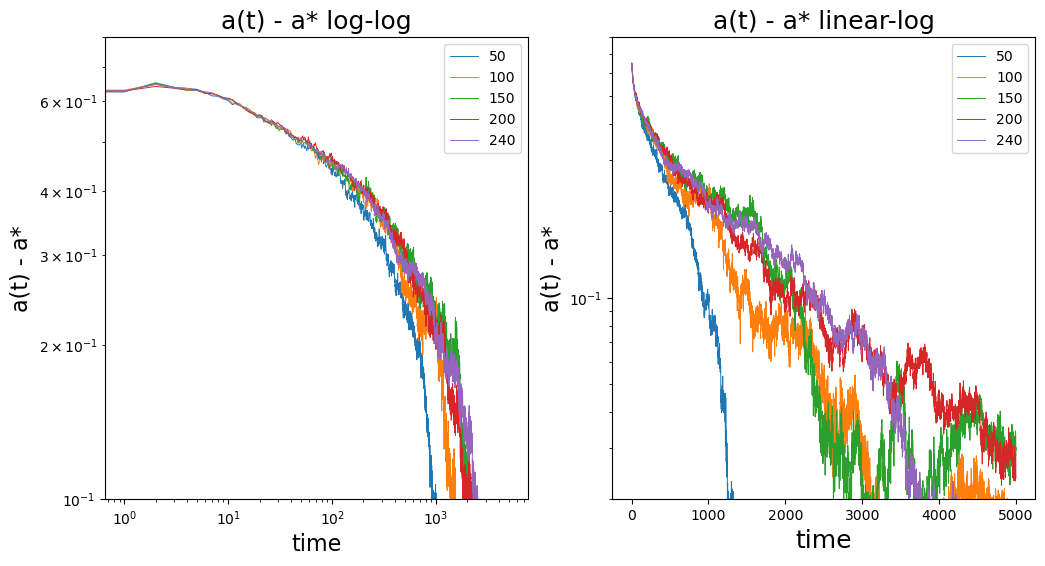

In [16]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
for i in range(len(mean_activities)):
    ax[1].plot(range(T), mean_activities[i], lw = 0.7, label = f"{L[i]}")
ax[1].set_yscale("log")
ax[1].set_ylim(0.02,0.8)
ax[1].set_xlabel("time", fontsize = 18)
ax[1].set_ylabel("a(t) - a*", fontsize = 16)
ax[1].set_title("a(t) - a* linear-log", fontsize = 18)
ax[1].legend()


for i in range(len(mean_activities)):
    ax[0].plot(range(T), mean_activities[i], lw = 0.7, label = f"{L[i]}")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_ylim(0.1,0.8)
# ax[0].set_xlim(1,1000)
ax[0].set_xlabel("time", fontsize = 16)
ax[0].set_ylabel("a(t) - a*", fontsize = 16)
ax[0].set_title("a(t) - a* log-log", fontsize = 18)
ax[0].legend()

plt.show()

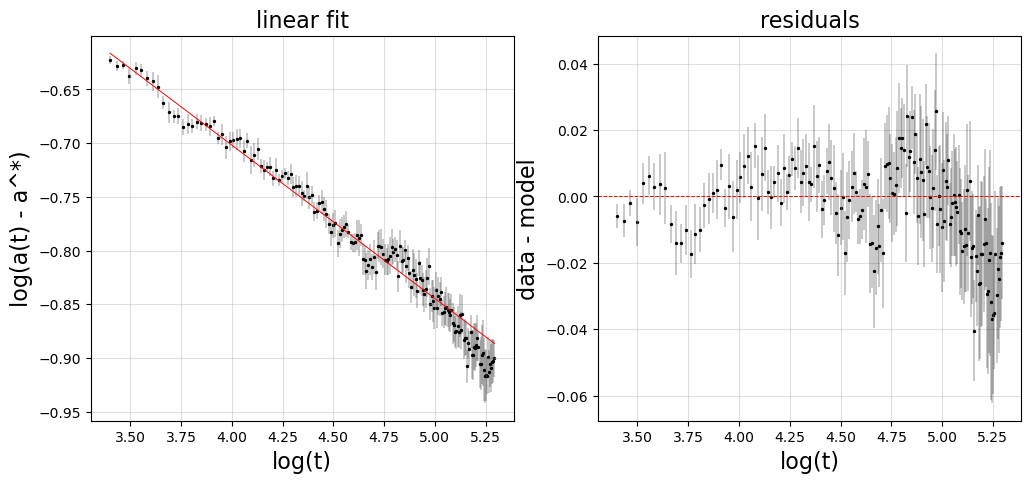

b:  0.0014205865691613291


In [21]:
x = range(30,200)
y = np.array(mean_activities)[-1, x]
err = np.array(mean_std)[-1, x]

err = err/np.abs(y)
x = np.log(x)
y = np.log(y)


def func(x, m, q):
    return m*x + q
    
popt, pcov = sp.optimize.curve_fit(func, x, y, sigma = err)
#popt, pcov = sp.optimize.curve_fit(func, x, y)

b, q = popt
errb, errq = np.sqrt(np.diag(pcov))

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,5))
xlin = np.linspace(x.min(), x.max())
ax[0].scatter(x,y, s = 2, color = "black")
ax[0].errorbar(x, y, err/np.sqrt(N[-1]), capsize = 0, color = "black", ls = "", lw = 0.3)
ax[0].plot(xlin, func(xlin,b,q), color = "red", lw = 0.7)
ax[0].set_xlabel("log(t)", fontsize = 16)
ax[0].set_ylabel("log(a(t) - a^*)", fontsize = 16)
ax[0].set_title("linear fit", fontsize = 16)
ax[0].grid(alpha = 0.4)


ax[1].scatter(x,y-func(x,b,q), s = 2, color = "black", )
ax[1].errorbar(x,y-func(x,b,q),err/np.sqrt(N[-1]),capsize = 0, color = "black", ls = "", lw = 0.3)
ax[1].axhline(0, color = "red", ls = "--", lw = 0.7)
ax[1].grid(alpha = 0.4)
ax[1].set_xlabel("log(t)", fontsize = 16)
ax[1].set_ylabel("data - model", fontsize = 16)
ax[1].set_title("residuals", fontsize = 16)

plt.show()

print("b: ", errb)
#print("b: ", -b, " +/- ", errb)

### Pair correlation function

Let's consider a live cell. If we determine how many live cells exist at a distance $[r,r+dr)$ and we divide that number by $2\pi r dr$ we get a density. Taking the average of this over all live cells (with periodic boundary conditions) gives us the mean density of live cells at a distance r from a generic one. Finally, if we divide every entry of the resulting histogram by the average density of the world at a precise time step we can see how the radial density differs from the global one. The presence of deviations could higlight some kind of information on how the cells tent to organize themsevles. Mathematically for avery bin we calculate <br>
$g(r) = \frac{1}{N_a d(t)} \frac{N_r}{2\pi rdr}$

In [17]:
initial_density = 0.4
L = 300
T = 5000

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

def pair_correlation_function(world, r_max):
    coord = np.argwhere(world == 1)
    diff = np.abs(coord[:,None,:] - coord[None,:,:])
    diff = np.minimum(diff,world.shape-diff)
    dist = np.sqrt(np.sum(diff**2, axis=2))
    dist = dist[np.triu_indices(dist.shape[0], 1)]
    hist, bin_edges = np.histogram(dist, bins=30, range=(0, r_max), density=False)
    r = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    dr = bin_edges[1]-bin_edges[0]
    N = np.sum(world == 1)
    mean_density = N/L**2
    hist = (1/(N*mean_density*np.pi*dr))*hist/r
    return (hist, bin_edges, r, dr)
    
world = np.random.random((L,L))
world[world > initial_density] = 0
world[world != 0] = 1

r_max = L/5
t_ref = [10, 50, 100, 200, 500, 700, 1000, 2000, 3000, 4000]
pair_corr_funcs = []
for t in range(T):
    world = evolve(world)
    if( t in t_ref):
        pair_corr_funcs.append(pair_correlation_function(world, r_max)) 

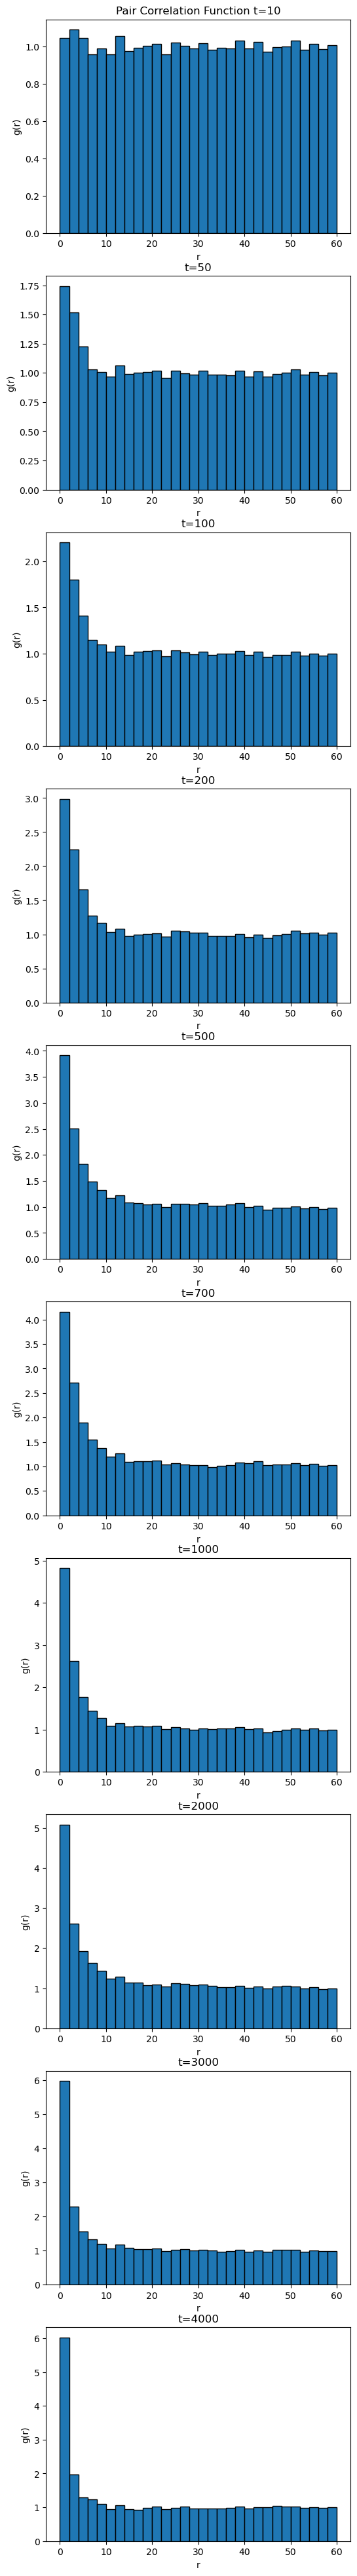

In [18]:
fig, ax = plt.subplots(nrows = len(pair_corr_funcs), figsize = (6,50))

for i in range(len(pair_corr_funcs)):
    ax[i].bar(pair_corr_funcs[i][2], pair_corr_funcs[i][0], width = pair_corr_funcs[i][3], edgecolor = 'k', align = 'center')
    #ax[i].plot(pair_corr_funcs[i][2], pair_corr_funcs[i][0])
    ax[i].set_xlabel("r")
    ax[i].set_ylabel("g(r)")
    ax[i].set_title(f"t={t_ref[i]}")
ax[0].set_title(f"Pair Correlation Function t={t_ref[0]}")
plt.show()